# TP noté -- Statistical models for decision making - partie 2

Cet devoir noté est composé de deux exercices. Il sera idéalement réalisé en binome et éventuellement seul. Les réponses seront données dans un notebook qui indiquera clairement les **noms et prénoms des élèves** l'ayant realisé.


## Exercice 1

Nous souhaitons évaluer si un nouveau produit a un effet significatif sur le rendement de moteurs. Pour y répondre, ce rendement (*Efficiency*) a été mesuré sur deux types de moteurs (*Brand_1* et *Brand_2*) et en testant différents niveaux de concentration (*Concentration*) du produit. Les observations sont dans le fichier *E2_Efficiency_Obs.csv*. Plus spécifiquement, nous nous demandons :
- Le produit semble-t-il avoir un effet ?
- Cet effet est-il différent en fonction de la marque du moteur ?
- Cet effet dépend-il de la concentration du produit ?

### Question 1.1 

Ouvrez et observez les données. A leur vue, quelle vous semble être la réponse aux trois questions posées plus haut ?

In [3]:
import pandas
import numpy as np
import matplotlib.pyplot as plt


df=pandas.read_csv("./E1_Efficiency_Obs.csv",sep=',')

In [5]:
df


,Brand,Concentration,Efficiency
0,Brand_1,3.94790,3.2224
1,Brand_1,1.78380,1.5127
2,Brand_1,7.44150,4.3736
3,Brand_1,8.56250,5.2151
4,Brand_1,9.80020,5.4256
...,...,...,...
65,Brand_2,0.80066,3.5650
66,Brand_2,5.05470,4.5253
67,Brand_2,6.58950,5.3607
68,Brand_2,2.14950,3.8577


In [ ]:
# Il semble que plus la concentration du produit est élevée, plus l'efficacité est élevée, donc il
# semble bien y avoir un effet lié au produit.
# L'effet est identique pour les deux moteur mais il apparait que le moteur 2 soit plus efficace que le moteur 1, notamment a basse concentration.


### Question 1.2 

Afin de répondre aux questions, deux hypothèses sont formulées :
- Pour chaque marque de moteur, la relation entre la concentration et le rendement est supposée linéaire.
- La distribution du bruit des observations est supposé suivre une loi Normale centrée.

Quelle démarche de modélisation statistique allez-vous utiliser pour répondre aux trois questions posées en introduction ? Une fois la démarche bien expliquée, testez la sur les données observées afin de conclure sur l'efficacité du produit.

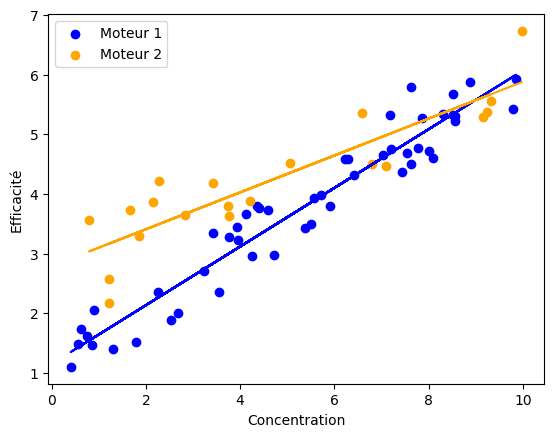

                            OLS Regression Results                            
Dep. Variable:             Efficiency   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     221.5
Date:                Wed, 17 Sep 2025   Prob (F-statistic):           2.20e-34
Time:                        12:06:39   Log-Likelihood:                -34.157
No. Observations:                  70   AIC:                             76.31
Df Residuals:                      66   BIC:                             85.31
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [ ]:
# La démarche de modélisation statistique que nous allons suivre est une analyse de la covariance. Nous
# avons une variable quantitative (l'efficacité) que nous voulons expliquer en fonction d'une variable
# quantitative (la concentration) et d'une variable qualitative (le moteur). Nous allons donc modéliser
# l'efficacité en fonction de la concentration et du moteur. Nous sommes dans le cas du cours ou 
# nous avons une variable quantitative et une variable qualitative. Nous allons donc utiliser une
# régression linéaire pour chaque sous groupe (moteur 1 et moteur 2) et comparer les deux régressions.
# On pourra ensuite tester différentes hypoyhèses sur les relations entre les sous groupes 
# avec des modèles réduits.
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import statsmodels.api as sm


T = df['Brand'].unique()

subset1 = df[df['Brand'] == T[0]]
subset2 = df[df['Brand'] == T[1]]

X1 = subset1['Concentration'].values.reshape(-1, 1)
y1 = subset1['Efficiency'].values
X2 = subset2['Concentration'].values.reshape(-1, 1)
y2 = subset2['Efficiency'].values

lr1 = LinearRegression().fit(X1, y1)
lr2 = LinearRegression().fit(X2, y2)

beta_0_1 = lr1.intercept_
beta_1_1 = lr1.coef_[0]

beta_0_2 = lr2.intercept_
beta_1_2 = lr2.coef_[0]

plt.scatter(X1, y1, color='blue', label='Moteur 1')
plt.scatter(X2, y2, color='orange', label='Moteur 2')
plt.plot(X1, lr1.predict(X1), color='blue')
plt.plot(X2, lr2.predict(X2), color='orange')
plt.xlabel('Concentration')
plt.ylabel('Efficacité')
plt.legend()
plt.show()

#On veut maintenant mettre en lumière des différences entre les deux groupes, donc les deux moteurs
#On va réécrire le modèle de régression linéaire pour tester différentes hypothèses.
#On a deux groupes, donc on peut écrire le modèle de régression linéaire comme

#on choisit un groupe de référence, par exemple le moteur 2 mais ici on n'a que deux groupes donc le choix n'a pas d'importance
#On utilise la libraire statsmodels pour réaliser l'ancova

# Modèle complet avec interaction
model_full = smf.ols("Efficiency ~ Concentration * Brand", data=df).fit()
print(model_full.summary())

# 1) Test de même pente (interaction inutile ?)
model_no_interaction = smf.ols("Efficiency ~ Concentration + Brand", data=df).fit()
anova1 = sm.stats.anova_lm(model_no_interaction, model_full)
print("\nTest de même pente (interaction) :\n", anova1)

# 2) Test de l'effet de la concentration (modèle sans concentration)
model_no_concentration = smf.ols("Efficiency ~ Brand", data=df).fit()
anova2 = sm.stats.anova_lm(model_no_concentration, model_full)
print("\nTest de l'effet de la concentration :\n", anova2)

# 3) Test de même origine (intercept identique entre marques)
#   -> comparer modèle avec ou sans Brand
model_no_brand = smf.ols("Efficiency ~ Concentration", data=df).fit()
anova3 = sm.stats.anova_lm(model_no_brand, model_full)
print("\nTest de même origine (effet de Brand) :\n", anova3)

# Conclusion :
# Pour les 3 tests, on rejette H0 au seuil 5% (p-value < 0.05)
# ainsi, on conclut qu'il y a une interaction entre la concentration et la marque (pente différente),
# que la concentration a un effet significatif sur l'efficacité, et que la marque a aussi un effet significatif
# sur l'efficacité (ordonnée à l'origine différente entre les marques).
# Cela confirme notre analyse visuelle initiale.


## Exercice 2


Afin d'estimer efficacement le niveau de fatigue des ailes d'un d'avion au cours des années, il a été proposé de lancer une étude pour évaluer s'il était possible de déduire le niveau de stress subit par les ailes de l'avion lors de phases de vols diverses avec de données capteurs acquises en routine pendant les vols. Une personne ayant une expertise mécanique sur le modèle d'avion étudié a alors quantifié le niveau de stress subi par les ailes dans différentes phases de vols et différents contextes. Nous allons mettre en lien ces niveaux de stress avec des données capteurs acquises au même moment que les annotations. Nous allons pour cela utiliser la régression linaire. 


### QUESTION 2.1

Les données d'apprentissage sont dans les fichiers *E2_sensor_vals.csv* et *E2_stress_vals.csv*. Ouvrez ces fichiers et mettez les données dans des numpy arrays ou des pandas dataframes *X* et *Y*. Représentez alors le lien entre les valeurs issues de chaque capteur et le niveau de stress dans des nuages de points 2D. Identifiez-vous des relations entre des données capteur et le niveau de stress ? Quels capteurs vous paraissent être les plus pertinents.
 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing


X = pd.read_csv("./E2_sensor_vals.csv", sep=';')
Y = pd.read_csv("./E2_stress_vals.csv", sep=';')

X

,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17
0,10.8,7.1,4.10,7.9,14.2,9.67,32.16,15.15,14.113333,0.24,0.2858,-3.092822,9.57,0.24,72.131613,4.34,3.77
1,10.8,7.1,5.58,7.7,12.5,9.93,28.30,11.90,11.180000,0.32,0.6628,-3.201752,8.00,0.29,72.010274,5.00,8.62
2,10.8,6.1,4.26,6.6,14.6,15.64,32.20,8.93,8.926667,0.44,-0.9030,-10.828537,13.23,0.17,82.606835,3.18,-1.53
3,11.0,4.4,3.37,5.5,13.3,8.31,29.55,14.42,12.980000,0.26,-0.1893,-1.695580,12.38,0.19,146.395830,4.56,-2.06
4,11.0,4.8,3.86,5.6,13.0,7.52,20.38,9.17,7.453333,0.19,0.6871,-4.242367,11.49,0.20,111.073272,2.34,2.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,8.4,4.7,3.50,5.8,11.6,11.01,38.64,50.00,12.593333,0.02,0.2802,-2.805721,14.62,0.16,93.053618,6.35,6.72
60,8.5,5.4,3.92,6.3,13.1,11.31,26.57,10.60,9.546667,1.10,0.9818,-3.453573,16.26,0.14,87.484607,4.05,-9.74
61,8.9,4.8,3.45,5.6,13.5,9.18,41.71,50.00,18.213333,0.01,0.9721,-1.081324,12.66,0.18,74.601643,5.44,6.14
62,9.0,4.8,3.73,5.6,12.7,12.22,27.59,9.96,9.013333,1.16,-0.9790,-9.210272,21.53,0.11,20.959932,4.71,-0.79


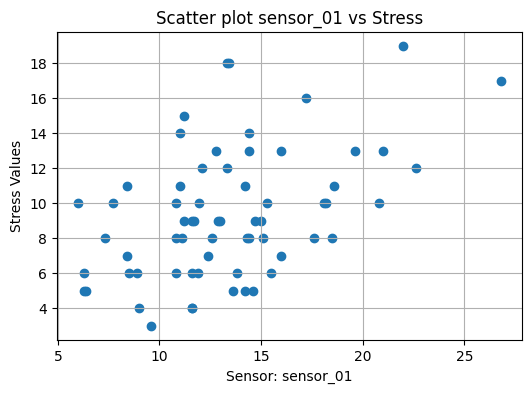

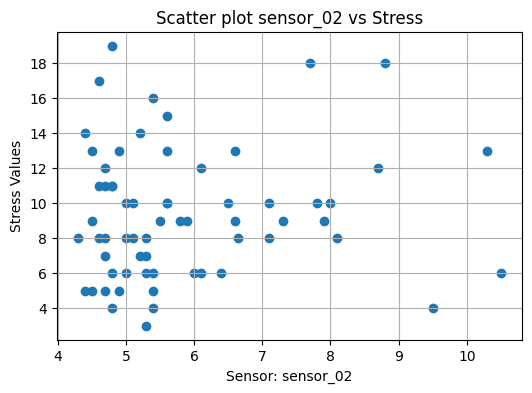

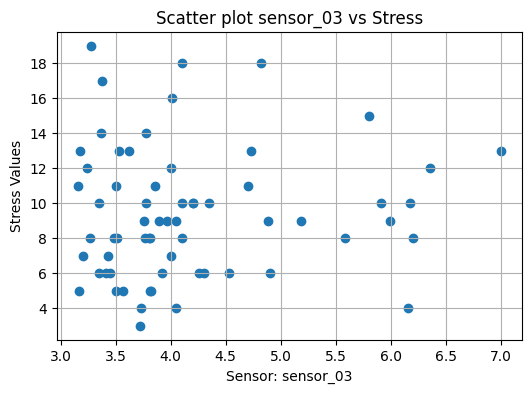

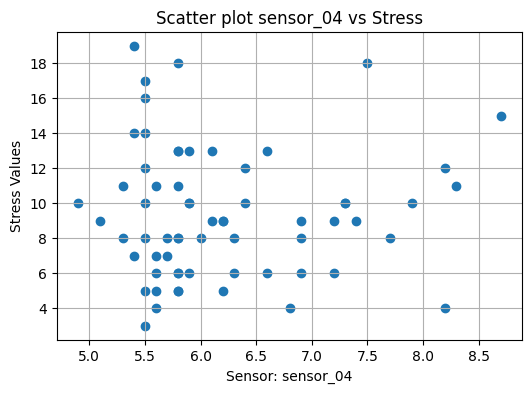

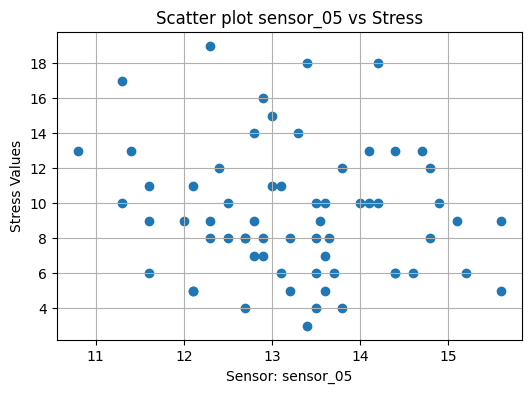

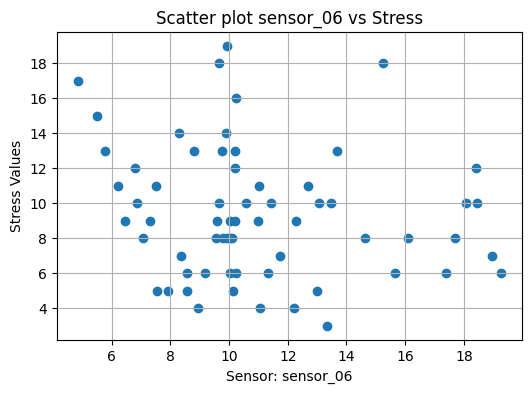

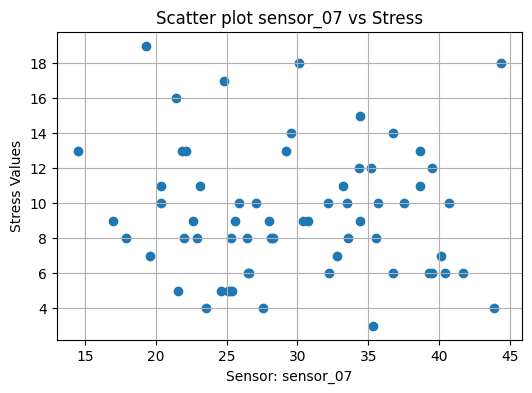

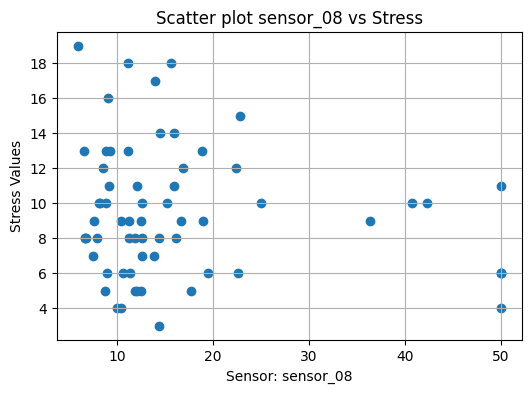

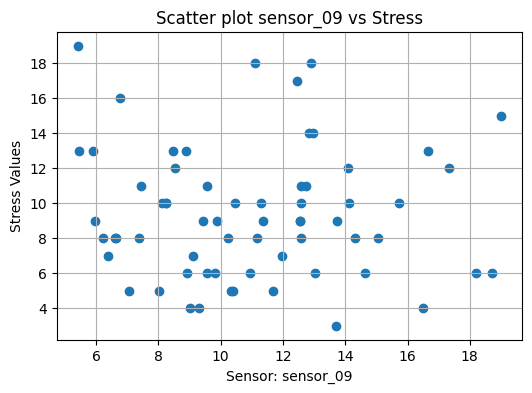

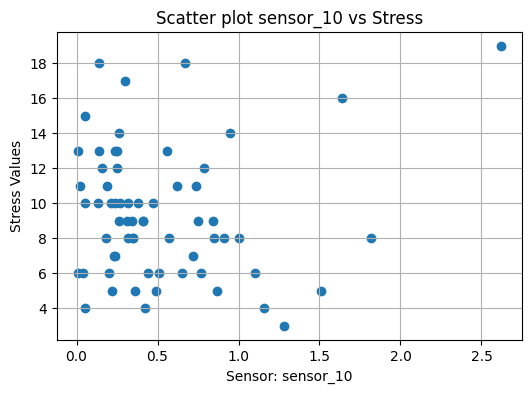

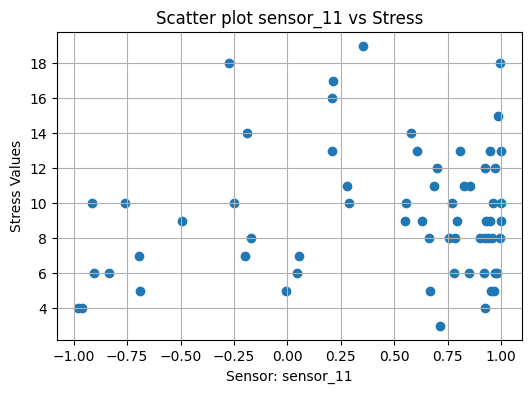

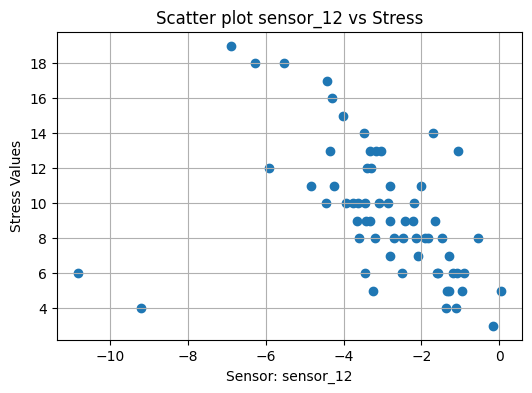

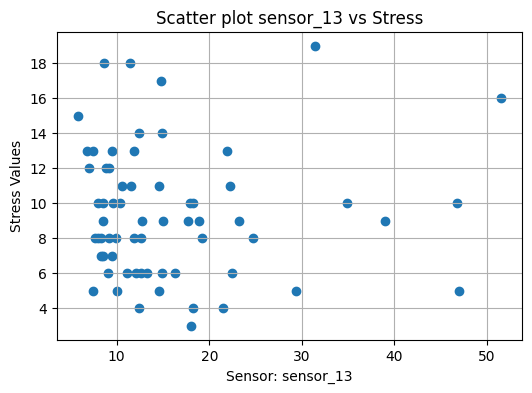

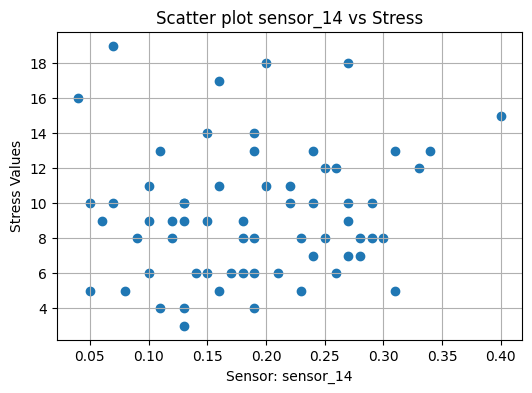

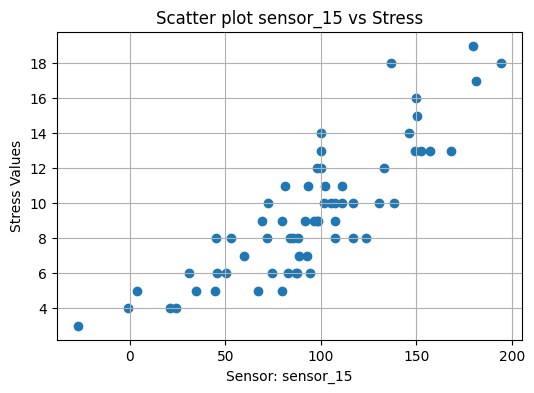

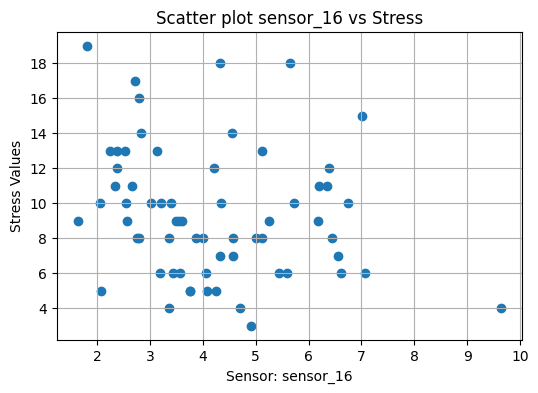

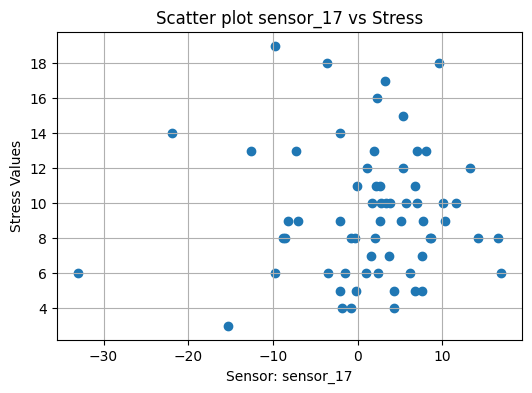

In [3]:

for col in X.columns:
    x = X[col].values.flatten()  # valeurs du capteur
    plt.figure(figsize=(6,4))
    plt.scatter(x, Y)
    plt.xlabel(f'Sensor: {col}')
    plt.ylabel('Stress Values')
    plt.title(f'Scatter plot {col} vs Stress')
    plt.grid(True)
plt.show()

#il semble en effet que certains capteurs aient une relation linéaire avec le stress, tandis que d'autres semblent n'avoir aucune relation apparente.
#Par exemple, les capteurs 1, 12 et 15 ont l'air d'avoir une relation linéaire avec les stress


### QUESTION 2.2
On se demande s'il est possible de prédire le niveau de stress à partir d'**une seule** des variables *sensor_01*, *sensor_12* ou *sensor_15*.


#### QUESTION 2.2.1

Effectuez une régression linéaire simple entre chacune de ces trois variables et le niveau de stress. Quelle stratégie de validation croisée vous semble être la plus adaptée sur ce jeu de données ?


#### QUESTION 2.2.2

Peut-on statistiquement affirmer qu'il existe une relation significative entre le niveau de stress et (indépendament) *sensor_01*, *sensor_12* ou bien *sensor_15* ? Si oui, décrivez votre procédure de test.


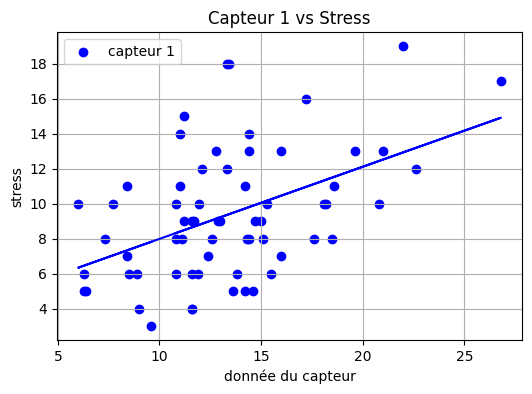

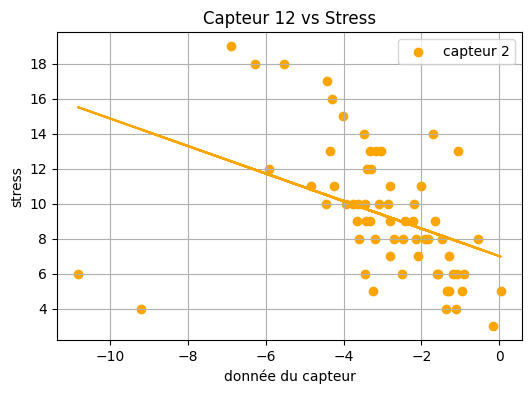

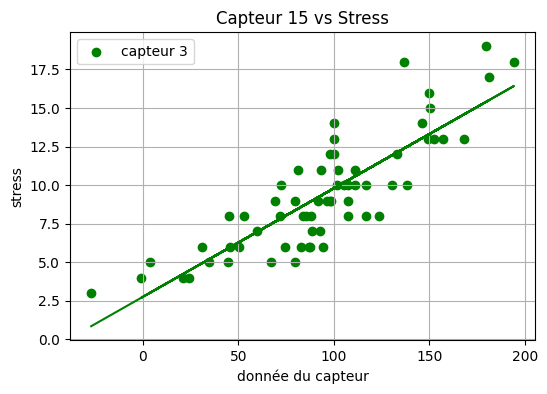


Résultats pour sensor_01
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     17.59
Date:                Mon, 22 Sep 2025   Prob (F-statistic):           8.87e-05
Time:                        15:18:51   Log-Likelihood:                -166.22
No. Observations:                  64   AIC:                             336.4
Df Residuals:                      62   BIC:                             340.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8693     

In [ ]:
#2.2.1
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import statsmodels.api as sm

X_01 = X['sensor_01'].values.reshape(-1, 1)
X_12 = X['sensor_12'].values.reshape(-1, 1)
X_15 = X['sensor_15'].values.reshape(-1, 1)
y = Y['Stress'].values

lr01 = LinearRegression().fit(X_01, y)
lr12 = LinearRegression().fit(X_12, y)
lr15 = LinearRegression().fit(X_15, y)


# Figure 1 : capteur 1
plt.figure(figsize=(6,4))
plt.scatter(X_01, y, color='blue', label='capteur 1')
plt.plot(X_01, lr01.predict(X_01), color='blue')
plt.xlabel('donnée du capteur')
plt.ylabel('stress')
plt.legend()
plt.title("Capteur 1 vs Stress")
plt.grid(True)
plt.show()

# Figure 2 : capteur 2
plt.figure(figsize=(6,4))
plt.scatter(X_12, y, color='orange', label='capteur 2')
plt.plot(X_12, lr12.predict(X_12), color='orange')
plt.xlabel('donnée du capteur')
plt.ylabel('stress')
plt.legend()
plt.title("Capteur 12 vs Stress")
plt.grid(True)
plt.show()

# Figure 3 : capteur 3
plt.figure(figsize=(6,4))
plt.scatter(X_15, y, color='green', label='capteur 3')
plt.plot(X_15, lr15.predict(X_15), color='green')
plt.xlabel('donnée du capteur')
plt.ylabel('stress')
plt.legend()
plt.title("Capteur 15 vs Stress")
plt.grid(True)
plt.show()

# Ici, même si on a peu de points (64), on préférera le KFold car la variance de l'estimateur est plus faible que pour le Leave-One-Out.
# Comme nous sommes dans un problème d'aéronautique, il est crucial d'avoir une estimation stable et fiable de la performance du modèle
# d'où l'utilisation du KFold.

#2.2.2
# Etant donné l'allure des tracés, on peut modéliser le stress par une rélation linéaire avec les capteurs 1, 12 et 15, indépendemment
# les uns des autres. On aurait donc un modèle de la forme :
# Stress = beta_0 + beta_1 * sensor_01 + beta_2 + epsilon pour le capteur 1 par exemple.
# On réalise ensuite le test avec l'hypothèse H_0 : beta_1 = 0
# On estime beta_1_chapeau avec la régression linéaire et on réalise le test de Student pour savoir si on rejette ou non H_0. On suppose
# pour cela que les erreurs suivent une loi normale et que la variance des erreurs est constante pour toutes les variables.
# On réalise le test grâce à la librairie statsmodels qui nous donne directement la p-value associée au test.

def test_regression(X, y, sensor_name):
    # Ajout de l'ordonnée à l'origine
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit() #On refait la régression linéaire avec statsmodels
    
    print(f"\nRésultats pour {sensor_name}")
    print(model.summary())

    p_value = model.pvalues[1]  # p-value de la variable explicative
    if p_value < 0.05:
        print(f"Relation significative (p = {p_value:.4f} < 0.05)")
    else:
        print(f"Pas de relation significative (p = {p_value:.4f} >= 0.05)")
    return model

# Tester chaque capteur
model01 = test_regression(X_01, y, "sensor_01")
model12 = test_regression(X_12, y, "sensor_12")
model15 = test_regression(X_15, y, "sensor_15")



### QUESTION 2.3

On s'intéresse maintenant au lien entre la variable *sensor_12* et le niveau de stress. On peut remarquer qu'il semble exister une relation linéaire entre ces variables, mais que les données contiennent aussi deux valeurs aberrantes.


#### QUESTION 2.3.1

**Stratégie 1** : Quelle stratégie utiliseriez vous pour détecter automatiquement des données aberrantes dans un jeu de données ?

#### QUESTION 2.3.2

**Stratégie 2** : Nous allons ici utiliser toutes les observations pour l'apprentissage du modèle linéaire et sa validation. En supposant que les erreurs de prédiction suivent une loi normale centrée, pourrait-on aussi détecter les outliers à partir d'un test d'hypothèse. Si oui, décrivez la procédure.


In [ ]:
#2.3.1 
# Pour détecter automatiquement des données aberrantes dans un jeu de données, on pourrait utiliser l'analyse des résidus du modèle
# de régression linéaire et étudier la distance de Cook pour identifier les points influents.

In [ ]:
#2.3.2


### QUESTION 2.4


Nous supprimerons dans cette question les deux observations qui sont aberrantes sur la variable *sensor_12*.

Nous souhaitons maintenant sélectionner automatiquement un nombre réduit, mais supérieur à 1, de capteurs qui nous permettraient de prédire au mieux le niveau de stress. Nous allons pour cela utiliser la régression multiple avec un terme de régularisation.

#### QUESTION 2.4.1

Avant d'effectuer une régression linéaire régularisée, il est vivement conseillé d'effectuer une étape de centrage réduction des données. Pourquoi ?


#### QUESTION 2.4.2

Décrivez votre démarche de sélection de variables et vos résultats. Est-ce que l'utilisation des données capteurs vous semble fiable ? 


#### QUESTION 2.4.3

Quelle démarche auriez-vous pour rendre compte des résultats de cette étude sachant que les données contenaient tout de même deux outliers ?



In [ ]:
#2.4.1 
# Il vaut mieux centrer et reduire les données car les données n'ont pas du tout la même échelle selon le capteur. Le régression régularisée n'aurait donc aucun 
# sens si on ne normalise pas les données

#2.4.2
# Nous allons utiliser Lasso car il semble que 3 variables explicatives soient suffisantes pour modéliser le stress. 
# Cette méthode va permettre de faire de la sélection de variables en forçant certains coefficients à être nuls.
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Centrer et réduire les données

alpha = 0.3  # Paramètre de régularisation
kfold = KFold(n_splits=8)  # Leave-One-Out Cross-Validation
sum_mse_scores=0.
for train, test in kfold.split(X_scaled):
    X_train=X_scaled[train]
    y_train=y[train]
    X_test=X_scaled[test]
    y_test=y[test]
  
    lasso_regressor = Lasso(alpha=alpha)
    lasso_regressor.fit(X_train, y_train)
  
    y_pred_lasso = lasso_regressor.predict(X_test)
    mse_score_lasso = mean_squared_error(y_test, y_pred_lasso)
    sum_mse_scores+=mse_score_lasso

print("alpha :", alpha, "\n", "mean MSE: ",sum_mse_scores/len(X_scaled))

lasso_regressor.fit(X_scaled, y)
# Variables sélectionnées (coefficients != 0)
selected_features = X.columns[lasso_regressor.coef_ != 0]

print("Variables sélectionnées par Lasso :")
print(selected_features)

# Etant donné les valeurs du stress, on a une mse assez faible (0.59), donc on peut considérer que le modèle explique correctement les variations du stress.
# Par ailleurs, on retrouve bien les capteurs 1, 12 et 15 qui semblaient avoir une relation linéaire avec le stress.


alpha : 0.3 
 mean MSE:  0.5927607832933911
Variables sélectionnées par Lasso :
Index(['sensor_01', 'sensor_08', 'sensor_12', 'sensor_15'], dtype='object')


Variance de y : 13.5469
